# CSC5034Z Assignment 2

Names: Kananelo Chabeli <br>
Student Number: CHBKAN001 <br>
Due Date: 18 May 2026 <br>


In [39]:
#Import modules
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from nltk.metrics.distance import edit_distance
import random

In [40]:
#setrandom seed for reproducability
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# 1. Data Processing

## 1.2 Data Processing Utilities

In [41]:
def build_vocab(words, vocab_size = 100, is_phoneme = False):
    """
        Builds the char-to-index vocabulary of the given list of english of phoneme words.
        
        English words are strings(will need to be converted to list of chars) while
        phonemes are strings where chars are separated by space. is_phoneme indicates what vocabulary needs
        to be build and handles these difference gracefully.
        
        Params:
            words(list[str]):List of string of English words or Phoneme Characters.
            vocab_size(int): The expected size of this vocabulary. Defaults to 100.
            is_phoneme(bool): indicates whether or not the required mapping is for phoneme or english chars.
        Returns:
            word_to_idx: a dictionary of keyed by most probable characters and values as indices. include special
            chars: <PAD>, <SOS>, <EOS> and <UNK>.
    """
    
    #use collections Counter to track occurances automatically.
    
    counter = Counter()
    
    for word in words:
        #if is_phoneme, chars in each word are space separated
        #if English words, use list(str) to get list of characters of that string
        counter.update(word.upper().split() if is_phoneme else list(word.lower()))
    word_to_idx = {
        '<PAD>': 0, #special token for padding shorter words.
        '<SOS>': 1, #special token that indicates start of the word.
        '<EOS>': 2,#special token indicating end of the word.
        '<UNK>': 3, #special token for unknown characters
    }
    #couter.most_common() returns tuple of most common characters in the given text
    
    for char, _ in counter.most_common(vocab_size - 4): # we subtract 4 for th 4 special chars 
        word_to_idx[char] = len(word_to_idx)
    
    #return the mapping ( our vacabulary)
    return word_to_idx

def encode_word(word, vocabulary, max_len = 100, is_phoneme = False):
    """
        Tokenizes the given word (in to characters), maps to indices from list of characters, 
        
        Params:
            word(str): string to tokenize and encode.
            vocabulary(dict[str,int]): vocabulary that the word to be encoded comes from.
            max_len(int): maximum length allowed for each word. defaults to 100.
            is_phoneme(100): indicator if word is phoneme or not (need special treatment)
    """
    #tokenize the input word
    tokens = word.upper().split()[:max_len] if is_phoneme else list(word.lower())[:max_len]
    
    #reserve space for special tokens: <SOS> and <EOS>
    tokens = tokens[:max_len-2]
    
    #add special tokens at start and end
    tokens = ['<SOS>'] + tokens + ['<EOS>']
    
    #map tokens to the. unknown token replaced with 3 (token ID of <UNK>)
    token_ids = [vocabulary.get(token, 3) for token in tokens]
    
    #padd all short words with zeros
    token_ids +=[0]*(max_len - len(token_ids))
    
    return token_ids

def decode_word(tokens, vocabulary, is_phoneme = False):
    """
        Decodes the word from the tokenized form and returns its string representation.
        This is just the reverse of encode_word function above.

        Params:
            tokens(list): list of tokens of the word to decode.
            vocabulary(dict): vacabulary from which characters makig up the word are sampled from. keys are chars and values are indices.
            is_phoneme(bool): differentiate between decoding a phone and word. if true, results in captilized and space-separated phonemes.
        Return:
            str - a decoded word or phonemes from the given list of tokens.
    """
    #reverse the vocabulary dict
    rev_vocab = {k:v for v,k in vocabulary.items()}
    #build the word
    decoded_word = ' '.join([rev_vocab[tk] for tk in tokens]) if is_phoneme else ''.join([rev_vocab[tk] for tk in tokens])

    return decoded_word
        

In [42]:
def read_csv_data(filename):
    """
        Utility function to read grapheme-to-phoneme data from a CSV file and
        return two lists: words and their corresponding phoneme strings.

        The function performs basic cleaning by:
            1. Removing rows where either the 'word' or 'phonemes' field is missing
               (NaN values in the CSV).
            2. Converting both columns to strings.
            3. Stripping leading and trailing whitespace.

        This ensures that downstream functions such as build_vocab() and
        encode_word() receive only valid string inputs.

        Params:
            filename(str): Name or path of the CSV file to load.

        Returns:
            tuple[list[str], list[str]]:
                words: List of cleaned English words.
                phonemes: List of cleaned phoneme strings.
    """
    # Load CSV file into a DataFrame
    df = pd.read_csv(filename)

    # Remove rows where either column contains NaN
    df = df.dropna(subset=['word', 'phonemes'])

    # Convert to strings and remove surrounding whitespace
    df['word'] = df['word'].astype(str).str.strip()
    df['phonemes'] = df['phonemes'].astype(str).str.strip()

    # Return as Python lists
    return df['word'].tolist(), df['phonemes'].tolist()

In [43]:
def gen_histogram_data(lst):
    """
        lst is list for words or phonemes. The function returns data to plot
        histograms of word length and phoneme sequence length.

        For words, length is the number of characters.
        For phoneme strings, length is the number of space-separated phoneme tokens.

        Params:
            lst(list[str]): list of words or phoneme strings in the dataset.

        Returns:
            lengths(list[int]): Sorted unique sequence lengths.
            counts(list[int]): Number of sequences having each corresponding length.
    """

    # Count how many sequences have each length.
    length_counter = Counter()

    for item in lst:
        # Determine whether this is a phoneme string or a normal word.
        # If spaces are present, treat it as a phoneme sequence.
        if " " in item.strip():
            seq_len = len(item.strip().split())
        else:
            seq_len = len(item.strip())

        # Increment the count for this sequence length.
        length_counter[seq_len] += 1

    # Sort lengths so histogram bins are ordered.
    lengths = sorted(length_counter.keys())

    # Extract counts in the same order.
    counts = [length_counter[length] for length in lengths]

    return lengths, counts

In [44]:
class Seq2SeqDataset(Dataset):
    """
        Dataset wrapper for training, validation and test datasets.
        
    """
    def __init__(self, words, phonemes, word_voc, phoneme_voc, max_len = 100):
        """
            Wrapper of the dataset loaded from given csv filename.
            
            Params:
                
                words(list[str]): list of string of words.
                phonemes(list[str]): list of string of phonemes.
                word_voc(dict): vocabulary(created only on training dataset) for english chars
                phoneme_voc(dict): vocabulary (created only from training dataset) for eng
                max_len(int or tuple of  len=2): specifies sequence length f0r words and phonemes.
                if int both phonemes and words tokens will have same length. else must be tuple (src_seq_len, tgt_seq_len)
        """
        #record sequence lengths
        if isinstance(max_len, int):
            src_seq_len = tgt_seq_len = max_len
        else:
            src_seq_len, tgt_seq_len = max_len
        
        self.words = [torch.tensor(encode_word(word, word_voc, src_seq_len), dtype=torch.long)
                         for word in words
                     ]
        self.phonemes = [torch.tensor(encode_word(phoneme, phoneme_voc, tgt_seq_len, True), dtype = torch.long)
                         for phoneme in phonemes
                     ]
        
    def __len__(self):
        return len(self.phonemes)
    
    def __getitem__(self, idx):
        return self.words[idx],self.phonemes[idx]

## 1.2 Data Loading and Visualization

### Step 1: Load datasets from csv files

In [45]:
TRAIN_FILENAME = './data/g2p_train.csv'
TEST_FILENAME = './data/g2p_test.csv'
VAL_FILENAME = './data/g2p_val.csv'

train_words, train_phonemes = read_csv_data(TRAIN_FILENAME)
test_words, test_phonemes = read_csv_data(TEST_FILENAME)
val_words, val_phonemes = read_csv_data(VAL_FILENAME)

In [46]:
#snaity check
for i,(w,p) in enumerate(zip(train_words, train_phonemes),0):
    if i == 5:
        break
    print(f'sample-{i}: word = {w}, phonemes = {p}')

sample-0: word = vigil, phonemes = V IH1 JH AH0 L
sample-1: word = ethelinda, phonemes = EH0 TH EH0 L IY1 N D AH0
sample-2: word = yaney, phonemes = Y EY1 N IY0
sample-3: word = caniglia, phonemes = K AH0 N IH1 G L IY0 AH0
sample-4: word = sondra, phonemes = S AA1 N D R AH0


### Step 2: Create Word and Phoneme Vocabularies

Vocabularies are only created using training dataset!

In [47]:
WORD_VOCAB_SIZE = 30 #26 chars + 4 special chars
PHONEME_VOCAB_SIZE = 88 # ~84 chars + 4 special chars

WORD_VOCABULARY = build_vocab(train_words, WORD_VOCAB_SIZE,is_phoneme = False)
PHONEME_VOCABULARY = build_vocab(train_phonemes, PHONEME_VOCAB_SIZE, is_phoneme = True)


In [48]:
#sanity checks
print('WORD VOCABULARIES')
for i,(w,idx) in enumerate(WORD_VOCABULARY.items()):
    if i == 10:
        break
        
    print(f'word_{i} = {w}, index = {idx}')

print('PHONEME VOCABULARY')
for i,(w,idx) in enumerate(PHONEME_VOCABULARY.items()):
    if i == 10:
        break
        
    print(f'word_{i} = {w}, index = {idx}')

WORD VOCABULARIES
word_0 = <PAD>, index = 0
word_1 = <SOS>, index = 1
word_2 = <EOS>, index = 2
word_3 = <UNK>, index = 3
word_4 = e, index = 4
word_5 = a, index = 5
word_6 = r, index = 6
word_7 = i, index = 7
word_8 = n, index = 8
word_9 = s, index = 9
PHONEME VOCABULARY
word_0 = <PAD>, index = 0
word_1 = <SOS>, index = 1
word_2 = <EOS>, index = 2
word_3 = <UNK>, index = 3
word_4 = AH0, index = 4
word_5 = N, index = 5
word_6 = L, index = 6
word_7 = S, index = 7
word_8 = T, index = 8
word_9 = R, index = 9


### Step 3: Create Train, Test and Validation Dataset objects


In [49]:
WORD_SEQ_LEN = 16 #most english words are ~3-10 chars long, 16 handle those few extreme cases
PHONEME_SEQ_LEN = 16 #phonemes are mostly 10-12, 16 handles those wierdly pronounced words

train_dataset = Seq2SeqDataset(train_words, train_phonemes,
                              WORD_VOCABULARY,
                              PHONEME_VOCABULARY,
                              max_len = (WORD_SEQ_LEN, PHONEME_SEQ_LEN))

test_dataset = Seq2SeqDataset(test_words, test_phonemes,
                              WORD_VOCABULARY,
                              PHONEME_VOCABULARY,
                              max_len = (WORD_SEQ_LEN, PHONEME_SEQ_LEN))

val_dataset = Seq2SeqDataset(val_words, val_phonemes,
                              WORD_VOCABULARY,
                              PHONEME_VOCABULARY,
                              max_len = (WORD_SEQ_LEN, PHONEME_SEQ_LEN))

### Step 4: Create DataLoaders

In [50]:
BATCH_SIZE = 16 #take smaller batchsizes

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [51]:
#sanity checks
for b,(w,p) in enumerate(train_loader):
    if b == 5:
        break
    print(f'word_seq = {decode_word(w[b].tolist(), WORD_VOCABULARY)},\n phonemes_seq = {decode_word(p[b].tolist(),PHONEME_VOCABULARY, True)}\n')

word_seq = <SOS>procrastinated<EOS>,
 phonemes_seq = <SOS> P R AH0 K R AE1 S T AH0 N EY2 T AH0 D <EOS>

word_seq = <SOS>classified<EOS><PAD><PAD><PAD><PAD>,
 phonemes_seq = <SOS> K L AE1 S AH0 F AY2 D <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>

word_seq = <SOS>nagged<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>,
 phonemes_seq = <SOS> N AE1 G D <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>

word_seq = <SOS>aquilino<EOS><PAD><PAD><PAD><PAD><PAD><PAD>,
 phonemes_seq = <SOS> AA0 K W IY0 L IY1 N OW0 <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>

word_seq = <SOS>throneberry<EOS><PAD><PAD><PAD>,
 phonemes_seq = <SOS> TH R OW1 N B EH2 R IY0 <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>



Traing Dataset: 	5777
Testing Dataset: 	723
Validation Dataset: 	723


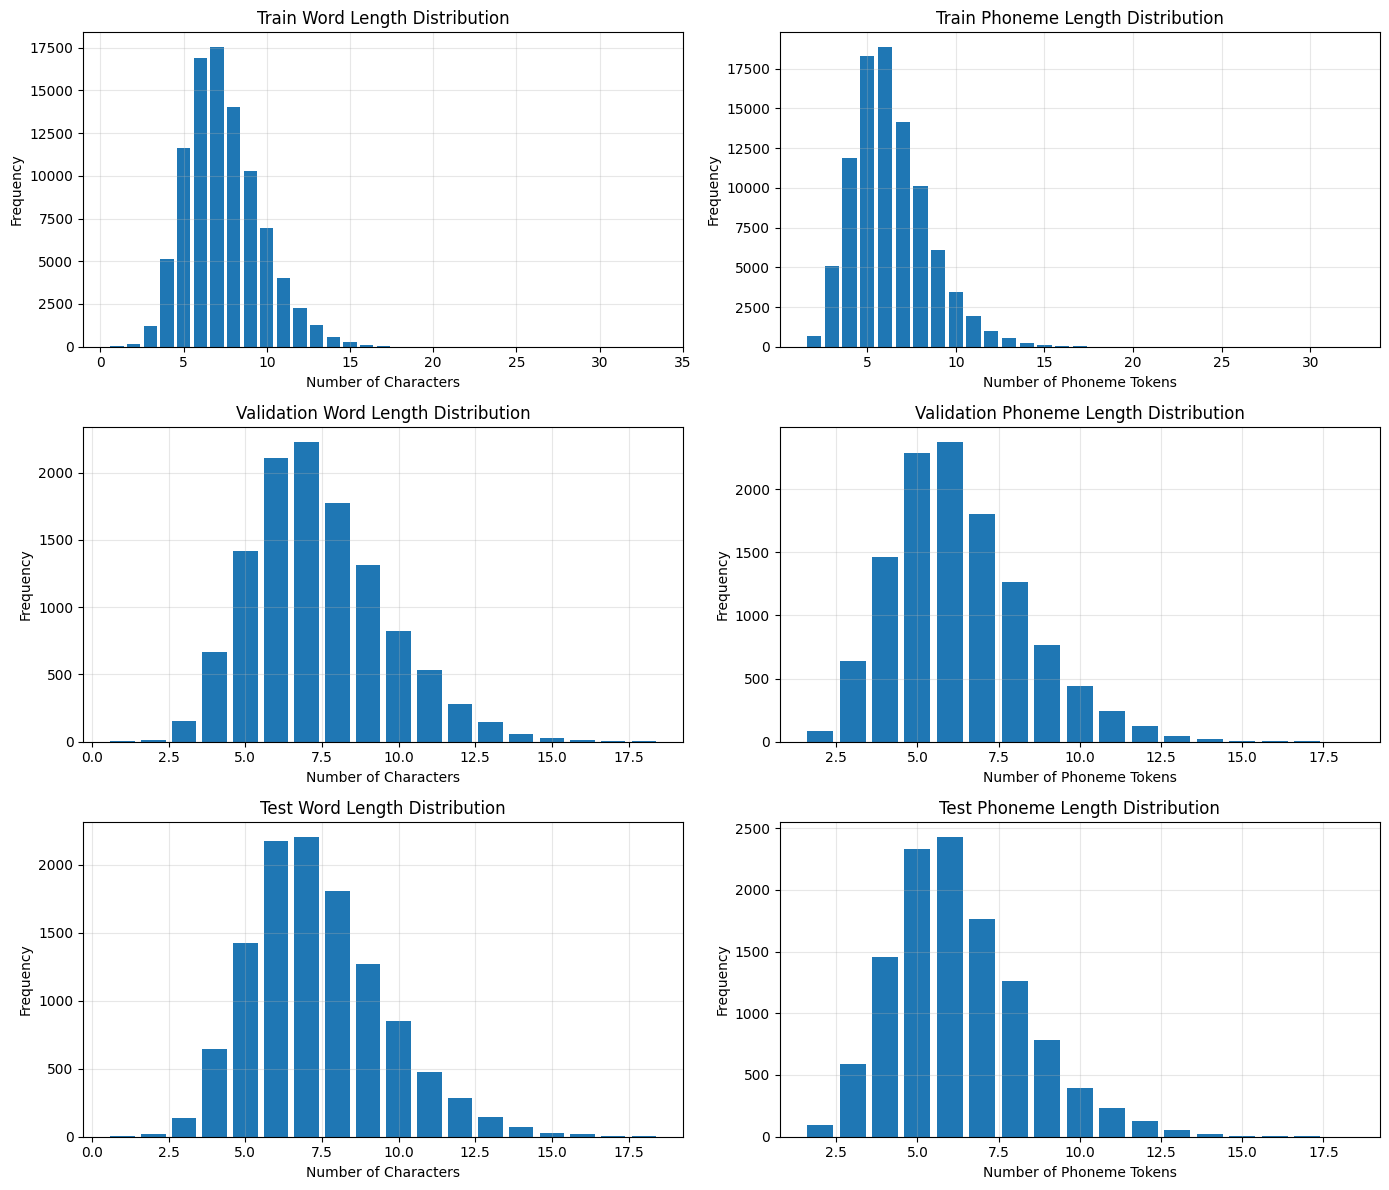

In [52]:
### Step 5: Report and Visualize word length distributions

print("="*65)
print(f"Traing Dataset: \t{len(train_loader)}")
print(f"Testing Dataset: \t{len(test_loader)}")
print(f"Validation Dataset: \t{len(val_loader)}")
print("="*65)

datasets = [
    ("Train", train_words, train_phonemes),
    ("Validation", val_words, val_phonemes),
    ("Test", test_words, test_phonemes),
]

# Create 3x2 subplot figure
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, (dataset_name, words, phonemes) in enumerate(datasets):

    # Generate histogram data
    word_lengths, word_counts = gen_histogram_data(words)
    phoneme_lengths, phoneme_counts = gen_histogram_data(phonemes)

    # Plot word-length histogram
    axes[row, 0].bar(word_lengths, word_counts)
    axes[row, 0].set_title(f"{dataset_name} Word Length Distribution")
    axes[row, 0].set_xlabel("Number of Characters")
    axes[row, 0].set_ylabel("Frequency")
    axes[row, 0].grid(True, alpha=0.3)

    # Plot phoneme-length histogram
    axes[row, 1].bar(phoneme_lengths, phoneme_counts)
    axes[row, 1].set_title(f"{dataset_name} Phoneme Length Distribution")
    axes[row, 1].set_xlabel("Number of Phoneme Tokens")
    axes[row, 1].set_ylabel("Frequency")
    axes[row, 1].grid(True, alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

# 2. LSTMCell and LSTMModel Implementations

In [53]:
class LSTMCell(nn.Module):
    """
        Implements an LSTM cell with 6 six governing equations implemented from scratch.
        
        The class is has the ability for to create context vector linear layers needed by the 
        Decoder Model
        
        The object is instantiated with input_size and hidden_size values.
    """
    def __init__(self, input_size, hidden_size, is_decoder = False):
        """
            Creates a new LSTMCell object with given input_size and hidden_Size dimensions.
            
            Params:
                input_size(int): Integer indicating the dimension of the input vectors at each time step.
                hidden_size(int): Integer indicating the dimension of the hidden and cell states.
                is_decoder(bool): Indicate whether the cell should include context vector or not 
                for Decoder model. Defaults to False.
        """
        super().__init__()
        #store hidden_Size for easy access
        self.is_decoder =  is_decoder
        #Implementing FORGET GATE of the cell
        self.input_forget_gate = nn.Linear(input_size, hidden_size, bias = False) #Create Weight matric for Input
        self.hidden_forget_gate = nn.Linear(hidden_size, hidden_size, bias = False)
        self.bias_forget_gate = nn.Parameter(torch.zeros(hidden_size))
        
        #include the contex vector layer if needed.
        if is_decoder:
            self.context_forget_gate = nn.Linear(hidden_size, hidden_size, bias = False)
        #Implement INPUT GATE
        self.input_in_gate = nn.Linear(input_size, hidden_size, bias = False) #Create Weight matric for Input
        self.hidden_in_gate = nn.Linear(hidden_size, hidden_size, bias = False)
        self.bias_in_gate = nn.Parameter(torch.zeros(hidden_size))
        if is_decoder:
            self.context_in_gate = nn.Linear(hidden_size, hidden_size, bias = False)
        
        #Implement OUTPUT GATE
        self.input_out_gate = nn.Linear(input_size, hidden_size, bias = False) #Create Weight matric for Input
        self.hidden_out_gate= nn.Linear(hidden_size, hidden_size, bias = False)
        self.bias_out_gate = nn.Parameter(torch.zeros(hidden_size))
        #Add context vector's Linear layer for Decoder model
        if is_decoder:
            self.context_out_gate = nn.Linear(hidden_size, hidden_size, bias = False)
        
        #Implement CANDIDATE CELL STATE
        self.input_candidate_cell = nn.Linear(input_size, hidden_size, bias = False) #Create Weight matric for Input
        self.hidden_candidate_cell = nn.Linear(hidden_size, hidden_size, bias = False)
        self.bias_candidate_cell = nn.Parameter(torch.zeros(hidden_size))
        #Add context vectot candidate cell layer if decoder in implemented
        if is_decoder:
            self.context_candidate_cell = nn.Linear(hidden_size, hidden_size, bias = False)
    
    def forward(self,x, prev_hidden_state, prev_cell_state, context_vector = None):
        """
            Computes forward pass of the LSTMCell and returns hidden and cell states at current step.
            
            Params:
                input_t(torch.tensor): A tensor of input feature vector at time step i, propagated through the cell.
                prev_hidden_state(torch.tensor): The hidden state vector from the previous time step.
                prev_cell_state(torch.tensor): The cell state vector from the previus time step.
        
        """
        
        #Forwardpass if performed differently for when the lstm is used in decoder or encoder.
        if self.is_decoder: #if so, outputs of all gates must include context vectors
            if context_vector is None:
                raise ValueError("Expected context_vector not to be None.")
            
            #compute output of FORGET gate
            forget_gate = F.sigmoid(self.input_forget_gate(x) + 
                                    self.hidden_forget_gate(prev_hidden_state) + 
                                    self.context_forget_gate(context_vector) + #add context vector to forget gate
                                    self.bias_forget_gate)

            #Compute output of INPUT gate
            input_gate = F.sigmoid(self.input_in_gate(x) + 
                                   self.hidden_in_gate(prev_hidden_state) +
                                   self.context_in_gate(context_vector) +  #add context vector to input gate
                                   self.bias_in_gate)

            #compute the output of OUTPUT gate
            output_gate = F.sigmoid(self.input_out_gate(x) + 
                                    self.hidden_out_gate(prev_hidden_state) + 
                                    self.context_out_gate(context_vector) + #add context vector to output gate
                                    self.bias_out_gate)

            #Compute the candidate cell state output
            candidate_cell_state = F.tanh(self.input_candidate_cell(x) + 
                                          self.hidden_candidate_cell(prev_hidden_state) + 
                                          self.context_candidate_cell(context_vector) + #add context vector to candidate cell.
                                          self.bias_candidate_cell)
        else:#implement gates for a normal LSTMCell ( no context vector to factor in)
            #compute output of FORGET gate
            forget_gate = F.sigmoid(self.input_forget_gate(x) + 
                                    self.hidden_forget_gate(prev_hidden_state) + 
                                    self.bias_forget_gate)

            #Compute output of INPUT gate
            input_gate = F.sigmoid(self.input_in_gate(x) + 
                                   self.hidden_in_gate(prev_hidden_state) + 
                                   self.bias_in_gate)

            #compute the output of OUTPUT gate
            output_gate = F.sigmoid(self.input_out_gate(x) + 
                                    self.hidden_out_gate(prev_hidden_state) + 
                                    self.bias_out_gate)

            #Compute the candidate cell state output
            candidate_cell_state = F.tanh(self.input_candidate_cell(x) + 
                                          self.hidden_candidate_cell(prev_hidden_state) + 
                                          self.bias_candidate_cell)


        #Compute current time-step cell state
        cell_state = (forget_gate * prev_cell_state) + (input_gate * candidate_cell_state)

        #Compute current time-step hidden state
        hidden_state = output_gate * F.tanh(cell_state)
        
        return hidden_state, cell_state
        

In [54]:
class LSTMModel(nn.Module):
    """
        Define an arbitrarily deep LSTMModel which wraps the LSTMCell and processes the entire input sequence.
        
        This class is a direct parent of Encoder and Decoder classes. The only difference between these is that
        Decoder need context vector linear layers activated in the LTSMCell. This is controlled by is_decoder variable
        
    """
    def __init__(self, input_size, hidden_size, num_layers = 1, is_decoder = False):
        """
            Creates a new LSTMModel with given parameters.
            
                Params:
                    input_size(int): The dimension of the input feature vector as it. passed directly to LSTMCell.
                    hidden_size(int): The dimension of the hidden and cell states of the LSTM cells.
                    num_layers(Int): Number of layers that the network should have. Defaults to 1.
                    is_decoder(bool): Indicates if the network models decoder architecture or not. Default to False
        """
        
        super().__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        #Create the network with 'num_layers' layers
        self.cells = nn.ModuleList([LSTMCell(input_size if l == 0 else hidden_size, hidden_size, is_decoder)
                                     for l in range(num_layers)]
        )
    
    
    def forward(self, inputs, hidden = None):
        """
            Performs forward propagation of the given input throughout the network, and return the hidden 
            and cell states of the final LSTMCell.
            
            This function is intentionally left without considering Decoder's context vector. The 
            Decoder child class will override and implements its behaviors
            Params:
                inputs(torch.tensor): This is tensor of input embedding to perform forward pass. 
                (seq_len, batch_size, embed_dim).
                hidden(tuple of torch.tensors): Tuple of hidden and cell states of the previous 
                time step for each layer in the network.(batch_size, hidden_size).
        """
        seq_len, batch_size,_ = inputs.shape
        
        if hidden is None: #set hidden and cell states of all layers to zero
            hidden_states = [torch.zeros(batch_size, self.hidden_size, device = inputs.device)
                                for _ in range(self.num_layers)
                            ]
            cell_states = [torch.zeros(batch_size, self.hidden_size, device = inputs.device)
                              for _ in range(self.num_layers)
                          ]
        else:
            prev_hiddens, prev_cells = hidden
            hidden_states  = [prev_hiddens[l] for l in range(self.num_layers)]
            cell_states = [prev_cells[l] for l in range(self.num_layers)]
        
        #keeps track hidden states of the output LSTMCell for all  sequence steps.
        all_hidden_states = []
        
        #Iterate over entire 'seq_len' time steps
        for t in range(seq_len):
            input_t = inputs[t] #input @ time = t.
            
            #now iterate over the layers and propagate the input feature vector.
            for l, cell in enumerate(self.cells):
                #compute forward pass of each LSTM cell and update lists
                hidden_states[l], cell_states[l] = cell(input_t, hidden_states[l], cell_states[l])
                
                #no subsequent layers input is the hidden_state from the previous cell
                input_t = hidden_states[l]
            all_hidden_states.append(hidden_states[-1]) #-1 only selects the last hidden-states from the array.
        
        #stack the hidden states 
        all_hidden_states = torch.stack(all_hidden_states, dim = 0) #(num_layers, batch_size, hidden_size)
        hidden_states = torch.stack(hidden_states, dim = 0)         #(num_layers, batch_size, hidden_size)
        cell_states = torch.stack(cell_states, dim  = 0)            #(num_layers, batch_size, hidden_size)
        
        return all_hidden_states, (hidden_states, cell_states)
        

# 3. Encoder and Decoder Implementation

In [55]:
class Encoder(LSTMModel):
    """
        Encoder is basically just a normal LSTMModel, just differs with having source embedding
        built in it. Its make more sense to inherect from LSTMModel directly instead of nn.Module
    """
    def __init__(self, src_vocab_size,embed_dim,hidden_size, num_layers = 1):
        """
            Creates a new Encoder object with given parameters
            
            Params:
                src_vocab_size(int): The size of the source sequence vocabulary.
                embed_dim(int): The dimension of each source token embedding vector.
                hidden_size(int): The dimension of the hidden state vectors.
                num_layers(int): Number pf LSTMCells this model will have. Default to 1 layer.
                dropout(float): the probability value to dropout the components of the source tokens. Defaults to 0.25
        """
        
        super().__init__(embed_dim, hidden_size, num_layers, is_decoder = False)
        
        #creates an embedding for the source sequence tokens
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=0)
        
    def forward(self, src, hidden = None):
        """
            Propagates the given src tokens through the network. Its overrides the LSTModels, but uses it
            internal,, but calling it with correct word embedding.
            
            Params:
                src(torch.tensor): A batch of source tokens to process. Dimension is 
                (batch_size, seq_len)
                hidden(torch.tensor): Hidden states of the previous batch. will be used for batch synchronization.
            Returns:
                tuples of hidden and cell states
                all_h, (h_n, c_n), exactly as returned by super().forward
        """
        #get embedding of each token at pass through dropout layer
        embed = self.embedding(src)   #(batch_size, seq_src_len, embed_dim)
        embed = embed.transpose(0, 1) #(seq_len, batch_size, embed_dim)
        
        #Encode simply uses LSTMModel's forward function as it is, only passing correct embeddings for each token
        return super().forward(embed, hidden)
        

In [56]:
en = Encoder(10,10,10)

In [57]:
class Decoder(LSTMModel):
    """
        Decoder also is direct descendant of LSTMModel because it already has LSTMCell variable which can
        implement decoder forward pass equations (by setting is_decoder == True)
        
        This class will be used for three decoding scenarios. The when context_mode == 'none',
        hidden_state is only used as initial state of the decoder. 
        (Otherwise decode behaves just like normal LSTMModel
        as thus, id_decoder must be set to False only for this Mode) 
    """
    def __init__(self, tgt_vocab_size, embed_dim,
                 hidden_size,
                 num_layers = 1,
                 context_mode = 'none'):
        """
            Creates a new Decoder object with given parameters.
            
            Params:
                tgt_vocab_size(int): The size of the target sequence's vocabulary.
                embed_dim(int): The dimension of each embedding vector for target tokens.
                hidden_size(int): The size of the hidden state vectors.
                num_layer(int): Number of LSTM layer the model will have. defaults to 1
                context_mode(str): indicate the context vector mode of the decoder. one of ['none', 'fixed', 'atten']
        """
        #We initialize context vector weights of the LSTMCell by setting is_decoder = True,
        #and this only occurs when context_mode != 'none'.
        super().__init__(embed_dim, 
                         hidden_size,
                         num_layers,
                         is_decoder = context_mode != 'none')
        #Create the embedding for target tokens.
        self.embedding = nn.Embedding(tgt_vocab_size, 
                                      embed_dim, 
                                      padding_idx = 0)
        self.num_layers = num_layers
        #store the context mode
        self.context_mode = context_mode.lower()
        
        #Decoder's head for logits computation
        self.head = nn.Linear(hidden_size, tgt_vocab_size)
        
    def forward(self, tgt, hidden):
        """
            This implements Decoder's forward pass used ony during training. In this case,
            
            it uses teacher_forcing to make predictions. A seperate function is provided to be 
            used during inference.
            
            Params:
                tgt: Target token indices to retrieve from the decoder's  embeddings. 
                (batch_size, tgt_seq_len)
                hidden: hidden states of the Encoder ( only from encoder's last layer).
            Returns:
                logits: predicted logits of the target sequence
        """
        
        #get target embeddings are return
        embed = self.embedding(tgt) # (batch_size, trgt_seq_len, embed_dim)
        embed = embed.transpose(0,1) # (trg_seq_len, batch_size, embed_dim)
        seq_len,batch_size, embed_dim = embed.shape
        
        #get hiddden states
        #this can not be None because, it comes from encoder
        #enc_all_hidden_states = (src_seq_len, batch_size, hidden_size)
        #enc_hidden_state = (batch_size, hidden_size)
        #enc_cell_state = (batch_size, hidden_size)
        enc_all_hidden_states, (enc_hidden_state, enc_cell_state) = hidden
        
        #initialize hidden state of all layers using  Encoder's final layer's output
        #This initialization is indepent of the mode.
        dec_hidden_states  = [enc_hidden_state[-1] for _ in range(self.num_layers)]
        dec_cell_states = [enc_cell_state[-1] for _ in range(self.num_layers)]
        
        #keeps track logits states of the output Decoder's head for all  sequence steps.
        all_logits = []
        
        #Iterate over entire 'seq_len' time steps
        for t in range(seq_len):
            
            tgt_t = embed[t] #input @ time = t. (bath_size, embed_dim)
            
            #now iterate over the layers and propagate the input feature vector.
            for l, cell in enumerate(self.cells):
                #compute forward pass of each LSTM cell and update lists
                #here is where we must check context_mode
                if self.context_mode == 'none': #forward is similar for any normal LTSMModel
                    dec_hidden_states[l], dec_cell_states[l] = cell(tgt_t, 
                                                            dec_hidden_states[l], 
                                                            dec_cell_states[l])
                
                #fixed mode: pass the encoder's hidden state at every time step (same nothing changes here)
                elif self.context_mode == 'fixed':
                    dec_hidden_states[l], dec_cell_states[l] = cell(tgt_t, 
                                                            dec_hidden_states[l], 
                                                            dec_cell_states[l],
                                    #pass fixed hidden state to layer at each time step
                                                           enc_hidden_state[-1])
                elif self.context_mode == 'atten':
                    #this si where things get cool
                    #we use _get_context_vector to compute the cross_attention context vector
                    dec_hidden_states[l], dec_cell_states[l] = cell(tgt_t, 
                                                            dec_hidden_states[l], 
                                                            dec_cell_states[l],
                                    #pass cross-attention context vector to layer at each time step
                                                          self._get_cross_atten(dec_hidden_states[l],
                                                                               enc_all_hidden_states))
                else:
                    raise ValueError(f'What context is {self.context_mode}?')
                
                
                #subsequent layers input is the hidden_state from the previous cell
                tgt_t = dec_hidden_states[l]
            all_logits.append(self.head(dec_hidden_states[-1])) #-1 only selects the last hidden-states from the array.
        
        #stack the hidden states
        all_logits = torch.stack(all_logits, dim = 0) #(tgt_seq_len-1, batch_size, tgt_vocab_size)
        
        #hidden_states = torch.stack(hidden_states, dim = 0)
        #cell_states = torch.stack(cell_states, dim  = 0)
        
        return all_logits #here all we need is logits (not hidden states)
    
    
    def infer(self, hidden, start_token, end_token, max_len = PHONEME_SEQ_LEN-1):
        """
            Runs forward pass though the decoder decodes the information
            without knowing what target (uses autoregressive).
            
            Inference is very different from training process)
            
            Params:
                hidden(tuple[torch.tensor]): Hidden states of the encoder (useful for attention)
                start_token(torch.tensor): The starting token ntypicall will be <BOS> token. (batch_size, )
                end_token(torch.tensor): The token indicating end of the sequence <EOS>. (batch_size, )
                max_len(int): maximum number of tokens to output.
        """
        

        curr_token = start_token
        
        enc_all_hidden_states, (enc_hidden_state, enc_cell_state) = hidden
        
        #initialize the decoder
        dec_hidden_states = [enc_hidden_state[-1]
                                    for _ in range(self.num_layers)]

        dec_cell_states = [enc_cell_state[-1]
                                    for _ in range(self.num_layers)]
        output_logits, output_tokens = [], []
        
        finished = curr_token == end_token

        while (~finished).any() and len(output_logits) < max_len:
            #embed the current token
            y_t = self.embedding(curr_token) # (batch,embed_dim)
            
            #propagate this embedded token throughout the decoder and get logits

            #now iterate over the layers and propagate the input feature vector.
            for l, cell in enumerate(self.cells):
                #compute forward pass of each LSTM cell and update lists
                #here is where we must check context_mode
                if self.context_mode == 'none': #forward is similar for any normal LTSMModel
                    dec_hidden_states[l], dec_cell_states[l] = cell(y_t, 
                                                            dec_hidden_states[l], 
                                                            dec_cell_states[l])
                
                #fixed mode: pass the encoder's hidden state at every time step (same nothing changes here)
                elif self.context_mode == 'fixed':
                    dec_hidden_states[l], dec_cell_states[l] = cell(y_t, 
                                                            dec_hidden_states[l], 
                                                            dec_cell_states[l],
                                    #pass fixed hidden state to layer at each time step
                                                           enc_hidden_state[-1])
                elif self.context_mode == 'atten':
                    #this si where things get cool
                    #we use _get_context_vector to compute the cross_attention context vector
                    dec_hidden_states[l], dec_cell_states[l] = cell(y_t, 
                                                            dec_hidden_states[l], 
                                                            dec_cell_states[l],
                                    #pass cross-attention context vector to layer at each time step
                                                          self._get_cross_atten(dec_hidden_states[l],
                                                                               enc_all_hidden_states))
                else:
                    raise ValueError(f'What context is {self.context_mode}?')
                
                y_t = dec_hidden_states[l]
            
            logits = self.head(dec_hidden_states[-1])

            next_token = self.greedy_decode(logits) #(batch_size,)

            # Keep EOS for sequences already completed
            next_token = torch.where(
                finished,
                end_token,
                next_token
            )

            output_logits.append(logits)
            output_tokens.append(next_token)

            curr_token = next_token

            finished |= (curr_token == end_token)
        
        #return the logic
        output_logits = torch.stack(output_logits,dim = 0)  #(out_seq_len, batch_size,vocab_size)
    
        output_tokens = torch.stack(output_tokens, dim = 0) #(out_seq_len, batch_size)
        
        return output_logits, output_tokens
        
    
    def greedy_decode(self, logits):
        """
            returns the token IDs(int) of the most probable outputed logit.
            
            Params:
                logits(torch.tensor): output of the feedforward layer of the decoder. (batch_size,tgt_vocab_size)
        """
          #this is same as torch.argmax(torch.softmax(logits, dim =1), dim =1)
         #skipp softmax computation all along(Save us several milliseconds of inference time)
        return torch.argmax(logits, dim = 1) #(batch_size, )
        

    def _get_cross_atten(self, dec_hidden, enc_hiddens):
        """
            dec_hidden: Decoder's hidden state vector at decoder's time step t (batch_size, hidden_size)
            enc_hiddens: List of all encoders hiddens states over all encoder's time steps (src_seq_len,batch_size,hidden_size)

            Returns:
                context: Returns a cross-attenion context vector of dimensions (batch, hidden_size)
        """

        # Step 1: raw scores
        scores = [
            torch.sum(dec_hidden * enc_hidden, dim=1)   # (batch,)
            for enc_hidden in enc_hiddens
        ]

        # Convert list -> tensor
        scores = torch.stack(scores, dim=1)            # (batch, src_seq_len)

        # Step 2: normalize
        attn_weights = torch.softmax(scores, dim=1)    # (batch, src_seq_len)

        # Step 3: weighted sum
        weighted_states = [
            attn_weights[:, t].unsqueeze(1) * enc_hiddens[t]   # (batch, hidden_size)
            for t in range(enc_hiddens.size(0))
        ]

        context = torch.stack(weighted_states, dim=0).sum(dim=0)  # (batch, hidden_size)

        return context

In [58]:
class Seq2Seq(nn.Module):
    """
        A sequence to sequence wrapper uses Encoder-Decoder Wrapper
    """
    def __init__(self, encoder, decoder):
        """
            Creates a new object with given ecoder and decoder functions
            
            Params:
                encoder(Encoder): encoder part of this Seq2Seq model.
                decoder(Decoder): decoder part of this Seq2Seq model.
        """
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, tgt = None, strt_token = None, end_token = None, teacher_forcing = True):
        """
            Performs forward pass of the given input. tgt is used based on where or not the 
            its training or inference (determines by)
            
            Params:
                
        """
        enc_hiddens = self.encoder(src) # enc_hiddens = all_h, (h_n, c_n)
        
        if teacher_forcing: #use both tgt==None and teacher_forcing == True to set inference!
            return self.decoder(tgt, enc_hiddens)
        else:
            if strt_token is None or end_token is None:
                raise ValueError('Please provide valid start and end tokens')
            return self.decoder.infer(enc_hiddens, strt_token, end_token)

# 4 Training

In [59]:
class ModelTrainer:
    """
        Defines Model's model training environment and computes all necessary metrics and stats.
    """
    def __init__(self, model, epochs = 10, lr = 1e-3, wd = 1e-4):
        """
            Creates a ModelTrainer object to train given model.
            
            Params:
                model(Seq2Se2): Seq2Seq model to be trained by this object.
                epochs(int): number of passes to run through the training dataset.
        """
        self.model = model.to(DEVICE)
        self.epochs = epochs
        self.criterion = nn.CrossEntropyLoss(label_smoothing = 0.1,
                                            ignore_index = PHONEME_VOCABULARY['<PAD>'])
        self.optimiser  = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        self.scheduler  = optim.lr_scheduler.CosineAnnealingLR(self.optimiser, T_max = epochs)
   
    def _run_epoch(self, loader):
        """
            Runs one complete epoch for both training and validation or testing stages as controlled
            by is_train parameter.
            
            The function will run differently for any of these modes
            1. Training:
                Model is put in training mode -> Gradients are computed -> Parameters are updated.
    
            2. Validation/Test:
                Model is put in evaluation mode -> Gradients are NOT computed ->Parameters are NOT updated.
    
            Params
                loader(DataLoader): loader for wither training, validation or testing datasets.
                is_train(bool): Flag the controls the behaviour of the function. if True, model is trained,
                            gradients get computed, and parameter get updated. else model is only evaluated.
    
            Returns
                avg_loss(float) - Average loss over all batches.
    
            avg_accu(float) - Average token-level accuracy over all batches.
        """
    
        # Step 1: Set model mode.

        self.model.train()

        # Accumulators for epoch metrics
        total_loss = 0.0
        total_accu = 0.0

        # Step 2: Enable/disable gradient computation automatically.

        with torch.set_grad_enabled(True):
    
            for batch_n, (words, phonemes) in enumerate(loader, 1):
                # Step 3: Move batch to CPU/GPU.
                words = words.to(DEVICE)
                phonemes = phonemes.to(DEVICE)

                #debug
                # print(f'Input: {decode_word(words[batch_n-1].tolist(), WORD_VOCABULARY)}')
                # print(f'Expected Target: {decode_word(phonemes[batch_n-1].tolist(), PHONEME_VOCABULARY)}')
                
                # Step 4: Teacher forcing split.
                decoder_input = phonemes[:, :-1]
                decoder_target = phonemes[:, 1:]
    
                # Step 5: Clear old gradients.

                self.optimiser.zero_grad()
    
                # Step 6: Forward pass.
                logits = self.model(words, decoder_input)
    
                # Step 7: Flatten tensors for CrossEntropyLoss.

                logits = logits.reshape(-1, logits.size(-1))
                decoder_target = decoder_target.transpose(0, 1).reshape(-1)
    
            
                # Step 8: Compute cross-entropy loss.
                loss = self.criterion(logits, decoder_target)

                # Step 9: Backpropagation and parameter update.
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(self.model.parameters(),max_norm=1.0)
    
                self.optimiser.step()
    
               
                # Step 10: Accumulate metrics.
                total_loss += loss.item()
                predictions = self.model.decoder.greedy_decode(logits)

                mask = decoder_target != PHONEME_VOCABULARY['<PAD>']

                correct = (predictions[mask] == decoder_target[mask]).sum().item()
                total = mask.sum().item()
                total_accu += correct/total

                #debug
                # if batch_n == 3:
                #     break
    
        # Step 11: Compute epoch averages.
        avg_loss = total_loss / len(loader)
        avg_accu = total_accu / len(loader)
    
        return avg_loss, avg_accu
        
    def train(self, train_loader, val_loader, verbose = False, epochs = None, patience = 5):
        """
            Trains the model on the given loader object.
            
            Params:
                loader(DataLoader): a training data loader object encapsulating training dataset.
                verbose(bool): determines if output should be printed to the console. Defaults to False.
                epochs(bool): number of passes to make through the training dataset. if None, use self.epochs.
                patience(bool): number of iteration through which the training stops if no improvement in validation accuracy.
        """
        #mode is set automatically is _run_epoch
        epochs = epochs or self.epochs
        
        #collect training stats
        train_stats = {
            'loss': [],
            'accuracy' : []
        }
        val_stats = {
            'loss': [],
            'token_accuracy': [],
            'word_accuracy': [],
            'PER': []
        }
        best_acc = 0.0
        epochs_no_improve = 0
        
        for epoch in range(1, epochs+1): #Training loop. implements early stopping on validation loss
            #run training epoch throught model
            train_loss, train_accur = self._run_epoch(train_loader)
            
            #run validation epoch
            metrics = self.evaluate(val_loader)
            
            #print results if verbose enable
            if verbose:
                print(
                    f"Epoch {epoch}/{epochs}:\n"
                    f"\tTraining Loss     = {train_loss:.3f}, "
                    f"Training Token Accuracy = {train_accur:.3f}\n"
                    f"\tValidation Loss   = {metrics['loss']:.3f}, "
                    f"Token Accuracy = {metrics['token_accur']:.3f}\n"
                    f"\tWord Accuracy   = {metrics['word_accur']:.3f}, "
                    f"Phoneme Error Rate = {metrics['per']:.3f}")
            #collect stats
            train_stats['loss'].append (train_loss),
            train_stats['accuracy'].append(train_accur)
            val_stats['loss'].append(metrics['loss'])
            val_stats['token_accuracy'].append (metrics['token_accur'])
            val_stats['word_accuracy'].append(metrics['word_accur'])
            val_stats['PER'].append(metrics['per'])

            if metrics['token_accur']>best_acc:
                best_acc = metrics['token_accur']
                epochs_no_improve = 0
            else:
                epochs_no_improve+=1
                if epochs_no_improve >= patience:
                    if verbose:
                        print(f'Early stopping at epoch {epoch} with no improvement in token accuracy for {patience} epochs')
                    break
        
        return train_stats, val_stats
            
        
    def predict(self, word):
        """
            predicts the phonemes of the given word and returns that exact phoneme(as a string). 
            
            Params
                word(str): word to find translation for
            Returns:
                str - corresponding phoneme str predicted.
        
        """
        pass
        
    def evaluate(self, loader):
        """
            Returns model's overall evaluation over: loss, token accuracy, word accuracy and phoneme error rate in one pass.
    
            Params:
                loader(DataLoader): a dataloader object for which computations are to be computed over.
            Return:
                dict = performance metrics of the model. keys are 'loss', 'token_accur', 'word_accur', and 'per'(phoneme error rate).
        """
        # put the model to evaluation mode
        self.model.eval()
    
        # collect evaluation metrics
        metrics = {
            'loss': 0.0,
            'token_accur': 0.0,
            'word_accur': 0.0,
            'per': 0.0
        }
    
        # special token IDs
        PAD_IDX = PHONEME_VOCABULARY['<PAD>']
        SOS_IDX = PHONEME_VOCABULARY['<SOS>']
        EOS_IDX = PHONEME_VOCABULARY['<EOS>']
    
        # counters
        total_batches = 0
        total_tokens = 0
        correct_tokens = 0
        total_words = 0
        correct_words = 0
        total_per = 0.0

        #helper fuction to clean the sequence off special tokens.
        def clean_sequence(seq):
            """
            Remove special tokens:
            - skip <SOS>
            - stop at <EOS>
            - ignore <PAD>
            """
            cleaned = []
    
            for token in seq:
                if token == SOS_IDX:
                    continue
    
                if token == EOS_IDX:
                    break
    
                if token == PAD_IDX:
                    continue
    
                cleaned.append(token)
    
            return cleaned
    
        with torch.no_grad():
    
            for words, phonemes in loader:
                # Step 1: Move batch to device
                words = words.to(DEVICE)
                phonemes = phonemes.to(DEVICE)
    
                batch_size = words.size(0)
                total_batches += 1
                
                # Step 2: Prepare teacher forcing tensors for loss
                decoder_input = phonemes[:, :-1]   # includes <SOS>, excludes final token
                decoder_target = phonemes[:, 1:]   # excludes <SOS>
    
                # Step 3: Compute validation loss using teacher forcing
                logits_tf = self.model(words, decoder_input)
                # logits_tf: (tgt_seq_len-1, batch_size, vocab_size)
    
                logits_flat = logits_tf.reshape(-1, logits_tf.size(-1))
                target_flat = decoder_target.transpose(0, 1).reshape(-1)
    
                loss = self.criterion(logits_flat, target_flat)
                metrics['loss'] += loss.item()
    
                # Step 4: Token-level accuracy (teacher forcing logits)
                predictions = self.model.decoder.greedy_decode(logits_flat)    
                mask = target_flat != PAD_IDX
                correct_tokens += (
                    (predictions == target_flat) & mask
                ).sum().item()
    
                total_tokens += mask.sum().item()
    
                # Step 5: Autoregressive inference for word accuracy and PER
                start_token = phonemes[:, 0]  # <SOS>
    
                end_token = torch.full(
                    (batch_size,),
                    EOS_IDX,
                    dtype=torch.long,
                    device=DEVICE
                )
    
                _, pred_tokens = self.model(words,strt_token=start_token, end_token=end_token,
                    teacher_forcing=False)
    
                # pred_tokens: (pred_seq_len, batch_size)
                pred_tokens = pred_tokens.transpose(0, 1)
                # pred_tokens: (batch_size, pred_seq_len)
    
    
                # Step 6: Word accuracy and PER
                for i in range(batch_size):
    
                    target_seq = phonemes[i].tolist()
                    pred_seq = pred_tokens[i].tolist()
    
                    target_clean = clean_sequence(target_seq)
                    pred_clean = clean_sequence(pred_seq)
    
                    # Word accuracy
                    if pred_clean == target_clean:
                        correct_words += 1
    
                    # PER
                    if len(target_clean) == 0:
                        sample_per = 0.0 if len(pred_clean) == 0 else 1.0
                    else:
                        sample_per = edit_distance(pred_clean, target_clean)/len(target_clean)
                        
    
                    total_per += sample_per
                    total_words += 1
    
        # Step 7: Compute final averages
        metrics['loss'] = (
            metrics['loss'] / total_batches
            if total_batches > 0 else 0.0
        )
    
        metrics['token_accur'] = (
            correct_tokens / total_tokens
            if total_tokens > 0 else 0.0
        )
    
        metrics['word_accur'] = (
            correct_words / total_words
            if total_words > 0 else 0.0
        )
    
        metrics['per'] = (
            total_per / total_words
            if total_words > 0 else 0.0
        )
        
        return metrics

In [60]:
def plot_compare_Results(base_res, fixed_res, atten_res):
    """
        plots the comparative results of model's for loss, token accuracy, word accuracy and phoneme error rate

        Params:
            base_res(tuple): results returned have training base Se2Seq model.
            fixed_res(tuple): results returned when training fixed attention Sea2Seq model.
            atten_res(tutple): result returned when training a a cross-attention Seq2Seq model.
    """
    results = {
        'Validation Loss': (
            ('No Attention',    base_res[1]['loss']),
            ('Fixed Attention', fixed_res[1]['loss']),
            ('Cross Attention', atten_res[1]['loss'])
        ),

        'Token Accuracy': (
            ('No Attention',    base_res[1]['token_accuracy']),
            ('Fixed Attention', fixed_res[1]['token_accuracy']),
            ('Cross Attention', atten_res[1]['token_accuracy'])
        ),

        'Word Accuracy': (
            ('No Attention',    base_res[1]['word_accuracy']),
            ('Fixed Attention', fixed_res[1]['word_accuracy']),
            ('Cross Attention', atten_res[1]['word_accuracy'])
        ),

        'Phoneme Error Rate': (
            ('No Attention',    base_res[1]['PER']),
            ('Fixed Attention', fixed_res[1]['PER']),
            ('Cross Attention', atten_res[1]['PER'])
        )
    }

    # Number of epochs inferred from the baseline history.
    epochs = range(1, len(base_res[1]['loss']) + 1)

    # Create 2x2 subplot grid.
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        'Seq2Seq Architecture Comparison',
        fontsize=16,
        fontweight='bold'
    )

    # Plot each metric.
    for i, (title, metric_data) in enumerate(results.items()):
        ax = axes[i // 2, i % 2]
        
        for label, values in metric_data:
            ax.plot(
                epochs,
                values,
                marker='o',
                linewidth=2,
                markersize=4,
                label=label
            )

        # Axis titles and labels.
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')

        if title == 'Validation Loss':
            ax.set_ylabel('Loss')
        elif title == 'Phoneme Error Rate':
            ax.set_ylabel('PER')
        else:
            ax.set_ylabel('Accuracy')

        # Grid and legend.
        ax.grid(True, alpha=0.3)
        ax.legend()

        # Accuracy metrics should be shown between 0 and 1.
        if title in ('Token Accuracy', 'Word Accuracy'):
            ax.set_ylim(0.0, 1.0)

        # PER should be non-negative.
        if title == 'Phoneme Error Rate':
            ax.set_ylim(bottom=0.0)

    # Improve spacing.
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Display figure.
    plt.show()

# 5. Hyperparamer Tuning

I have adopted this random search funcvtion form my assignment 1

In [62]:

LEARNING_RATES = [1e-5, 1e-4, 1e-3]
EMBED_SIZE = [32, 128, 256]
HIDDEN_SIZE = [64, 128, 256]


def random_hyperparam_search(train_loader, val_loader, trials=10):
    """
        Performs 'trials' random searchs for the best coniguration.

        Params:
            train_loader(DataLoader): a training dataset loader.
            val_loadrr(DataLoader): a valiadation dataset loader
            trials(int): number of trials to perform the search of hyper parameters ( maximum itv 27 = 3x3x3)
        Returns:
            return  best config as tuple: lr, embed_size, hidden_size
    """

    if train_loader is None or val_loader is None:
        raise ValueError("Both train_loader and val_loader must be provided.")
    
    # Keep track of the best configuration discovered so far.
    best_word_accuracy = float('-inf')
    best_config = None
    best_metrics = None

    # Store all trial results for later inspection.
    search_results = []

    for trial in range(1, trials + 1):

        lr = random.choice(LEARNING_RATES)
        embed_dim = random.choice(EMBED_SIZE)
        hidden_size = random.choice(HIDDEN_SIZE)

        print(f'\nTrial {trial}/{trials}')
        print(f'  lr          = {lr}')
        print(f'  embed_dim   = {embed_dim}')
        print(f'  hidden_size = {hidden_size}')

        encoder = Encoder(src_vocab_size=WORD_VOCAB_SIZE,embed_dim=embed_dim,hidden_size=hidden_size)

        decoder = Decoder(tgt_vocab_size=PHONEME_VOCAB_SIZE,embed_dim=embed_dim,hidden_size=hidden_size,context_mode='none')

        model = Seq2Seq(encoder, decoder)

        # 3. Create trainer
        trainer = ModelTrainer(model,epochs=10,lr=lr)


        # 4. Train the model.(Don't need train reuslts)
        trainer.train(train_loader,val_loader,verbose=False,epochs=10)

        # 5. Evaluate on validation set.

        metrics = trainer.evaluate(val_loader)

        # Support either spelling convention.
        word_accuracy = metrics.get('word_accur',metrics.get('word_accuracy'))

        print(f'  Validation Word Accuracy = {word_accuracy*100:.4f}%')
        print(f'  Validation PER           = {metrics["per"]*100:.4f}%')

        # 6. Record results.
        trial_result = {'trial': trial,
                        'lr': lr,
                        'embed_dim': embed_dim,
                        'hidden_size': hidden_size,
                        'metrics': metrics
        }
        search_results.append(trial_result)

        # 7. Update best configuration.
        if word_accuracy > best_word_accuracy:
            best_word_accuracy = word_accuracy
            best_config = (lr, embed_dim, hidden_size)
            best_metrics = metrics

            print('  >>> New best configuration found.')

        # Release GPU memory before next trial.
        del model
        del trainer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Final summary.
    print('\n' + '=' * 60)
    print('BEST CONFIGURATION')
    print('=' * 60)
    print(f'Learning Rate : {best_config[0]}')
    print(f'Embedding Dim : {best_config[1]}')
    print(f'Hidden Size   : {best_config[2]}')
    print(f'Word Accuracy : {best_word_accuracy:.4f}')
    print(f'PER           : {best_metrics["per"]:.4f}')
    print('=' * 60)

    # Return:
    return best_config, best_metrics, search_results

In [63]:
#train results

In [64]:
config, metrics, search_Res = random_hyperparam_search(train_loader, val_loader)


Trial 1/10
  lr          = 1e-05
  embed_dim   = 128
  hidden_size = 256
  Validation Word Accuracy = 14.8793%
  Validation PER           = 40.2637%
  >>> New best configuration found.

Trial 2/10
  lr          = 0.001
  embed_dim   = 128
  hidden_size = 128
  Validation Word Accuracy = 53.4060%
  Validation PER           = 13.7948%
  >>> New best configuration found.

Trial 3/10
  lr          = 1e-05
  embed_dim   = 32
  hidden_size = 256
  Validation Word Accuracy = 6.5697%
  Validation PER           = 50.5482%

Trial 4/10
  lr          = 0.001
  embed_dim   = 256
  hidden_size = 64
  Validation Word Accuracy = 38.9336%
  Validation PER           = 21.3039%

Trial 5/10
  lr          = 1e-05
  embed_dim   = 128
  hidden_size = 256
  Validation Word Accuracy = 15.3640%
  Validation PER           = 39.2151%

Trial 6/10
  lr          = 0.0001
  embed_dim   = 32
  hidden_size = 64
  Validation Word Accuracy = 15.3553%
  Validation PER           = 38.9163%

Trial 7/10
  lr          = 1e-0

# 6. Architecture Comparision

In [65]:
#
MAX_EPOCHS = 30
NUM_LAYERS = 1

(0.001, 128, 128)

## 6.1 Create and Train Seq2Seq Model with No Attention

In [68]:
#create encoder
base_encoder = Encoder(WORD_VOCAB_SIZE,config[1], config[2],NUM_LAYERS)
#decoder
base_decoder = Decoder(PHONEME_VOCAB_SIZE, config[1], config[2], NUM_LAYERS, context_mode = 'none')
#seq2seq
base_seq2seq = Seq2Seq(base_encoder, base_decoder)
#trainer
base_trainer = ModelTrainer(base_seq2seq, epochs = MAX_EPOCHS, lr = config[0])

In [ ]:
base_res = base_trainer.train(train_loader, val_loader, verbose = True)

Epoch 1/30:
	Training Loss     = 1.709, Training Token Accuracy = 0.710
	Validation Loss   = 1.336, Token Accuracy = 0.828
	Word Accuracy   = 0.334, Phoneme Error Rate = 0.249
Epoch 2/30:
	Training Loss     = 1.274, Training Token Accuracy = 0.849
	Validation Loss   = 1.220, Token Accuracy = 0.863
	Word Accuracy   = 0.420, Phoneme Error Rate = 0.195
Epoch 3/30:
	Training Loss     = 1.195, Training Token Accuracy = 0.873
	Validation Loss   = 1.182, Token Accuracy = 0.876
	Word Accuracy   = 0.454, Phoneme Error Rate = 0.177
Epoch 4/30:
	Training Loss     = 1.155, Training Token Accuracy = 0.885
	Validation Loss   = 1.150, Token Accuracy = 0.886
	Word Accuracy   = 0.483, Phoneme Error Rate = 0.164
Epoch 5/30:
	Training Loss     = 1.129, Training Token Accuracy = 0.893
	Validation Loss   = 1.128, Token Accuracy = 0.892
	Word Accuracy   = 0.501, Phoneme Error Rate = 0.153
Epoch 6/30:
	Training Loss     = 1.110, Training Token Accuracy = 0.899
	Validation Loss   = 1.119, Token Accuracy = 0.8

## 6.2 Create and Train Seq2Seq2 with Fixed Attention

In [ ]:
fixed_encoder = Encoder(WORD_VOCAB_SIZE,config[1], config[2],NUM_LAYERS)

#decoder
fixed_decoder = Decoder(PHONEME_VOCAB_SIZE, config[1], config[2], NUM_LAYERS, context_mode = 'fixed')

#seq2seq
fixed_seq2seq = Seq2Seq(fixed_encoder, fixed_decoder)

#trainer
fixed_trainer = ModelTrainer(fixed_seq2seq, epochs = MAX_EPOCHS, lr = config[0])

In [ ]:
fixed_res = base_trainer.train(train_loader, val_loader, verbose = True)

## 6.3 Create and Train Seq2Seq2 with Cross-Attention

In [ ]:
atten_encoder = Encoder(WORD_VOCAB_SIZE,config[1], config[2],NUM_LAYERS)

#decoder
atten_decoder = Decoder(PHONEME_VOCAB_SIZE,config[1], config[2], NUM_LAYERS, context_mode = 'atten')

#seq2seq
atten_seq2seq = Seq2Seq(atten_encoder, atten_decoder)

#trainer
atten_trainer = ModelTrainer(atten_seq2seq, epochs = MAX_EPOCHS, lr = config[0])

In [ ]:
atten_res = base_trainer.train(train_loader, val_loader, verbose = True)

## 6.4 Visualize Results

In [ ]:
plot_compare_Results(base_res , fixed_res, atten_res)

# 7. Bottleneck Analysis

In [ ]:
def clean_sequence(seq):
            """
            Remove special tokens:
            - skip <SOS>
            - stop at <EOS>
            - ignore <PAD>
            """
            cleaned = []
    
            for token in seq:
                if token == SOS_IDX:
                    continue
    
                if token == EOS_IDX:
                    break
    
                if token == PAD_IDX:
                    continue
    
                cleaned.append(token)
    
            return cleaned

In [ ]:
def compute_length_bucket_accuracy(trainer, loader):
    """
    Computes word accuracy for different source word-length buckets.
        1-4 characters, 5-7 characters, 8-10 characters, 11+ characters

    Params:
        trainer(ModelTrainer): trained model trainer.
        loader(DataLoader): DataLoader containing the evaluation dataset.
    Returns:
        dict: {'1-4': accuracy,'5-7': accuracy,'8-10': accuracy','11+': accuracy
        }
    """

    PAD_IDX = WORD_VOCABULARY['<PAD>']
    SOS_IDX = WORD_VOCABULARY['<SOS>']
    EOS_IDX = WORD_VOCABULARY['<EOS>']

    bucket_names = ['1-4', '5-7', '8-10', '11+']

    def get_bucket(length):
        if length <= 4:
            return 0
        elif length <= 7:
            return 1
        elif length <= 10:
            return 2
        else:
            return 3

    trainer.model.eval()

    correct = [0, 0, 0, 0]
    total = [0, 0, 0, 0]

    with torch.no_grad():
        for words, phonemes in loader:

            words = words.to(DEVICE)
            phonemes = phonemes.to(DEVICE)

            # Count actual characters in each source word.
            valid_mask = (
                (words != PAD_IDX) &
                (words != SOS_IDX) &
                (words != EOS_IDX)
            )
            word_lengths = valid_mask.sum(dim=1)  # (batch_size,)

            # Run autoregressive inference.
            start_token = phonemes[:, 0]
            end_token = phonemes[:, -1]

            _, pred_tokens = trainer.model(
                words,
                strt_token=start_token,
                end_token=end_token,
                teacher_forcing=False
            )

            # (seq_len, batch_size) -> (batch_size, seq_len)
            pred_tokens = pred_tokens.transpose(0, 1)

            # Remove <SOS> from targets.
            target_tokens = phonemes[:, 1:]

            batch_size = words.size(0)

            for i in range(batch_size):

                # Determine bucket.
                length = word_lengths[i].item()
                bucket_idx = get_bucket(length)

                # Remove special tokens and padding.
                pred_seq = clean_sequence(pred_tokens[i].tolist())

                target_seq = clean_sequence(
                    target_tokens[i].tolist()
                )

                total[bucket_idx] += 1

                if pred_seq == target_seq:
                    correct[bucket_idx] += 1

    # Convert counts to accuracies.
    accuracies = {}
    for i, bucket_name in enumerate(bucket_names):
        if total[i] > 0:
            accuracies[bucket_name] = correct[i] / total[i]
        else:
            accuracies[bucket_name] = 0.0

    return accuracies


In [ ]:
def plot_length_analysis(base_bucket_acc, fixed_bucket_acc, atten_bucket_acc):
    """
    Plots a grouped bar chart comparing word accuracy by source word length.

    Params:
        base_bucket_acc(dict): output of compute_length_bucket_accuracy() for the no-attention model.
        fixed_bucket_acc(dict): output of compute_length_bucket_accuracy() for the fixed-attention model.
        atten_bucket_acc(dict): output of compute_length_bucket_accuracy() for the cross-attention model.
    """

    bucket_names = ['1-4', '5-7', '8-10', '11+']

    base_vals = [base_bucket_acc[b] for b in bucket_names]
    fixed_vals = [fixed_bucket_acc[b] for b in bucket_names]
    atten_vals = [atten_bucket_acc[b] for b in bucket_names]

    x = np.arange(len(bucket_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(x - width, base_vals, width, label='No Attention')
    ax.bar(x, fixed_vals, width, label='Fixed Attention')
    ax.bar(x + width, atten_vals, width, label='Cross Attention')

    ax.set_title('Word Accuracy vs Word Length')
    ax.set_xlabel('Word Length Bucket (characters)')
    ax.set_ylabel('Word Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_names)
    ax.set_ylim(0.0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
base_analysis = compute_length_bucket_accuracy(base_trainer, test_loader)
fixed_analysis = compute_length_bucket_accuracy(fixed_trainer, test_loader)
atten_analysis = compute_length_bucket_accuracy(atten_trainer, test_loader)

In [ ]:
plot_length_analysis(base_analysis, fixed_analysis, atten_analysis)

# References